## Imports and Data Loadings

In [1]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/cleaned_spam.csv')
# Handle any potential NaNs created during saving/loading
df = df.dropna(subset=['clean_message']) 

X = df['clean_message']
y = df['label']

# Stratify ensures the 86/14 ham/spam ratio is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Bag of Words and Model Training

In [2]:
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred = nb_model.predict(X_test_bow)

## Evaluation and Savings

Accuracy: 0.9775583482944344

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       964
           1       0.94      0.89      0.91       150

    accuracy                           0.98      1114
   macro avg       0.96      0.94      0.95      1114
weighted avg       0.98      0.98      0.98      1114



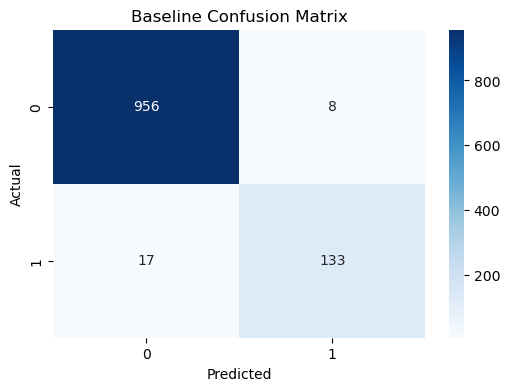

In [3]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save models for the deployment phase
with open('../models/bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('../models/naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb_model, f)